In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');

/* Global Fonts and Counters */
body, p, li, div {
    font-family: 'Inter', sans-serif;
}

body {
    counter-reset: h2counter;
}

/* Heading Fonts */
.usecase-header-bar,
.usecase-title,
.usecase-section-heading,
.usecase-sub-section-heading,
.usecase-sub-sub-section-heading,
.usecase-unnumbered-heading{
    font-family: 'Poppins', sans-serif;
}

.usecase-header-bar {
   padding: 16px 20px;
   background-color: #059669;
   color: #fff;
   border-radius: 6px 6px 0 0;
}

.usecase-title {
    font-size: 1.9em;
    font-weight: 800;
}

/* Metadata Styling */
.usecase-details {
    padding-left: 20px;
    padding-bottom: 8px;
    padding-top: 8px;
    font-size: 1.1em;
    color: #121212;
}

/* Base styling for all main headings (Numbered & Unnumbered) */
.usecase-section-heading, 
.usecase-unnumbered-heading {
    font-weight: 700;
    font-size: 1.35em;
    color: #059669;
    padding: 14px 4px 6px 4px;
    border-bottom: 3px solid #2DBE6C;
    margin-top: 10px;
}

/* Level 1 section headings */
.usecase-section-heading::before {
    content: none !important;
}

/* Level 2 subsection headings */
.usecase-sub-section-heading {
    font-weight: 600;
    font-size: 1.15em;
    color: #059669;
    margin-top: 8px;
}

.usecase-sub-section-heading::before {
    content: none !important;
}

/* Level 3 sub-subsection headings */
.usecase-sub-sub-section-heading {
    font-weight: 500;
    font-size: 1.05em;
    color: #059669;
    margin-top: 6px;
}

.usecase-sub-sub-section-heading::before {
    content: none !important;
}

/* Body */
.usecase-body {
    font-size: 1em;
    color: #121212;
    line-height: 1.6;
    margin-bottom: 8px;
}

/* Generic list styling */
.usecase-list {
    line-height: 1.7;
}

.usecase-list ul, .usecase-list ol {
    padding-left: 24px;
    margin-top: 8px;
    margin-bottom: 12px;
}

.usecase-list li {
    margin-bottom: 6px;
}

/* Datasets specific list box */
.usecase-datasets {
    background-color: rgba(5, 150, 105, 0.06);
    border-left: 4px solid #059669;
    padding: 12px 20px;
    border-radius: 0 4px 4px 0;
    margin-top: 12px;
}

.usecase-datasets ul {
    margin-top: 8px;
    margin-bottom: 8px;
}

/* Link styles for both TOC and Datasets */
.usecase-contents a, 
.usecase-datasets a {
    color: #059669;
    text-decoration: none;
}

.usecase-datasets a {
    font-weight: 500;
}

.usecase-contents a:hover, 
.usecase-datasets a:hover {
    text-decoration: underline;
}

/* TOC Container */
.usecase-contents {
    line-height: 1.9;
    padding-left: 20px;
}

/* Content Divider */
.usecase-code-divider {
    font-style: italic;
    color: rgba(18, 18, 18, 0.65);
    background-color: rgba(5, 150, 105, 0.06);
    padding: 10px 16px;
    border-radius: 4px;
    margin-top: 14px;
}
</style>

""")

<div class="usecase-header-bar">
    <div class="usecase-title">Parking Availability in the Melbourne CBD</div>
</div>

<div class="usecase-details"><b>Authored by: </b>Stefan Cucos (updated: Aidan Page)</div>
<div class="usecase-details"><b>Date Created: </b>Trimester 1, 2025</div>
<div class="usecase-details"><b>Time to Complete: </b>90 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, pandas, Requests, Folium, basic scikit-learn</div>


<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>


<div class="usecase-body"><b>As a</b> driver planning to park in the Melbourne CBD, <b>I want to</b> enter my destination and time of arrival into a parking assistant app, <b>so that I can</b> find available on-street parking spots, including time limits, hourly cost and payment method options.</div>

<div class="usecase-body">To answer that this use case connects the City of Melbourne's live parking datasets to a full month of archived sensor events. The live data shows what is happening right now (the archive shows what usually happens at a given hour in a given part of the city which is what a driver planning ahead actually needs).</div>


<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this use case will teach you</b></div>


<div class="usecase-body">By the end of this use case you will be able to:</div>

<div class="usecase-list">

- Connect to a real-time public API and handle its responses
- Join open datasets on their documented keys and diagnose a join that returns few matches
- Work with a large historical archive by filtering it down to a manageable extract
- Find and fix real data quality issues such as mixed types, impossible durations and artefact categories
- Turn event records into availability rates and a simple predictive model, evaluated against honest baselines
- Visualise parking availability on an interactive map

</div>


<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>


<div class="usecase-body">Finding on-street parking in the Melbourne CBD is time-consuming and circling for a bay adds congestion and emissions. The City of Melbourne has installed in-ground sensors in most CBD parking bays that report whether each bay is occupied, and publishes this alongside parking restriction and meter information through its Open Data Platform. It has also archived every sensor event from earlier years.</div>

<div class="usecase-body">This use case connects these datasets to explore current availability and build a simple model of when and where bays are likely to be free. Along the way it works through the kind of data quality and data transition issues that come up in almost any real open-data project.</div>


<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>


<div class="usecase-body">Four City of Melbourne datasets are used: three live API datasets and one historical archive.</div>

<div class="usecase-datasets">

<b>Live (City of Melbourne Open Data API)</b>

- [On-street Parking Bay Sensors](https://data.melbourne.vic.gov.au/explore/dataset/on-street-parking-bay-sensors/): near real-time occupancy status for each sensored bay
- [On-street Car Park Bay Restrictions](https://data.melbourne.vic.gov.au/explore/dataset/on-street-car-park-bay-restrictions/): restrictions per bay; joins to the sensors on the bay id, as documented by the City of Melbourne
- [On-street Car Parking Meters with Location](https://data.melbourne.vic.gov.au/explore/dataset/on-street-car-parking-meters-with-location/): meter locations and payment metadata

<b>Historical (archived)</b>

- [On-street Car Parking Sensor Data 2019](https://discover.data.vic.gov.au/dataset/on-street-car-parking-sensor-data-2019): every parking event for 2019 (42.7 million rows). A pre-filtered extract ships with this use case in the <code>DEPENDENCIES</code> folder, and the code that built it is shown in section 6.

</div>

<div class="usecase-body"><b>Note:</b> the City of Melbourne has flagged that its parking system is being upgraded and the live datasets may be disrupted. The City's API also rate-limits anonymous callers. The live cells below retry automatically and print a plain explanation if either happens, rather than failing with a cryptic error. The historical analysis from section 6 onward is unaffected.</div>


<div id="contents" class="usecase-unnumbered-heading"><b>Contents</b></div>


<div class="usecase-contents">

<ol>
<li><a href="#section-1">Set up the Python environment</a></li>
<li><a href="#section-2">Real-time parking bay status</a>
<div style="margin-left:24px;">2.1. <a href="#subsection-2-1">Mapping current occupancy</a></div>
</li>
<li><a href="#section-3">Parking restrictions data</a>
<div style="margin-left:24px;">3.1. <a href="#subsection-3-1">Data structure and missing values</a></div>
<div style="margin-left:24px;">3.2. <a href="#subsection-3-2">Visualising parking restrictions</a></div>
</li>
<li><a href="#section-4">Parking meter metadata</a>
<div style="margin-left:24px;">4.1. <a href="#subsection-4-1">Payment options and meter locations</a></div>
</li>
<li><a href="#section-5">Merging the live datasets</a></li>
<li><a href="#section-6">Historical parking events: the 2019 archive</a>
<div style="margin-left:24px;">6.1. <a href="#subsection-6-1">Loading the extract</a></div>
<div style="margin-left:24px;">6.2. <a href="#subsection-6-2">Cleaning the extract</a></div>
</li>
<li><a href="#section-7">Availability patterns</a>
<div style="margin-left:24px;">7.1. <a href="#subsection-7-1">Availability by hour of day</a></div>
<div style="margin-left:24px;">7.2. <a href="#subsection-7-2">Availability by day of week and area</a></div>
</li>
<li><a href="#section-8">Modelling: predicting bay availability</a></li>
<li><a href="#section-9">Predicting availability for an arrival time</a></li>
<li><a href="#section-10">Saving the trained model</a></li>
</ol>

</div>


<div id="section-1" class="usecase-section-heading"><b>1. Set up the Python environment</b></div>


<div class="usecase-body">Install any missing packages (only needed on Google Colab) and import the libraries used throughout the notebook: <code>requests</code> for the API calls, <code>pandas</code> for data handling, <code>matplotlib</code> and <code>seaborn</code> for charts, <code>folium</code> for maps and <code>scikit-learn</code> for the model. The cell also looks for an optional City of Melbourne API key in a <code>.env</code> file. Anonymous requests share a portal-wide monthly quota that can run out; a free key from the open data portal has its own quota. The notebook runs without a key, and the key itself must never be committed to the repository.</div>


In [2]:
# Suppress a harmless urllib3 notice about the system OpenSSL version
import warnings
warnings.filterwarnings("ignore", message="urllib3 v2 only supports OpenSSL")

# Install required packages (Colab only). Skip this line if running locally in a virtual environment.
!pip install -q --disable-pip-version-check requests pandas folium matplotlib seaborn scikit-learn joblib python-dotenv

# Import required libraries
import os, glob
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import Popup, CircleMarker
from IPython.display import HTML
from dotenv import load_dotenv

# Optional City of Melbourne API key. Anonymous calls share a domain-wide monthly quota that can run out;
# a free key (portal account -> API keys) has its own quota. Put MELBOURNE_API_KEY=... in a .env file next
# to this notebook, or export it in your shell. Never commit the key. The notebook works without one.
_ = load_dotenv()
API_KEY = os.environ.get("MELBOURNE_API_KEY")
print("API key:", "found" if API_KEY else "not set (using anonymous quota)")

def _with_key(url):
    """Append the API key to a request URL if one is configured."""
    return f"{url}&api_key={API_KEY}" if API_KEY else url

import time
from requests.exceptions import RequestException

def fetch_sample(dataset_id, limit=100, attempts=4):
    """Fetch up to `limit` rows from a City of Melbourne dataset, retrying if the API is rate-limited.

    The Open Data API caps anonymous callers at a rolling quota. When it is exceeded the API answers
    429 (Too Many Requests); this helper waits and retries a few times before giving up with a plain
    explanation, so a busy day does not look like a broken notebook.
    """
    url = _with_key(f"https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/{dataset_id}/records?limit={limit}")
    for attempt in range(1, attempts + 1):
        try:
            r = requests.get(url, timeout=60)
            if r.status_code == 429:
                wait = 30 * attempt
                print(f"Rate-limited by the API (429). Waiting {wait}s before retry {attempt}/{attempts}...")
                time.sleep(wait)
                continue
            r.raise_for_status()
            return pd.DataFrame(r.json().get("results", []))
        except RequestException as e:
            if attempt == attempts:
                raise RuntimeError(
                    f"Could not fetch '{dataset_id}' after {attempts} attempts: {e}\n"
                    "The City of Melbourne API is either rate-limiting anonymous callers or is disrupted by the "
                    "parking system upgrade. Wait a while and re-run this cell; the historical analysis from "
                    "section 6 onward does not depend on it."
                ) from e
            print(f"Request failed ({e}); retrying...")
            time.sleep(15)
    raise RuntimeError(f"Could not fetch '{dataset_id}': API quota still exceeded after {attempts} attempts. "
                       "Wait a while and re-run this cell.")


API key: found


<div id="section-2" class="usecase-section-heading"><b>2. Real-time parking bay status</b></div>


<div class="usecase-body">The parking bay sensor dataset is the closest thing to a live answer for a driver: it reports, for each sensored bay, whether a car is currently present. It is updated roughly every two minutes.</div>

<div class="usecase-body">This first request uses the <code>records</code> endpoint of the City of Melbourne Open Data v2.1 API, through the <code>fetch_sample()</code> helper defined in section 1. The endpoint returns at most 100 rows per call. That is enough to look at the structure of the data and put a sample on a map. Section 5 fetches the complete dataset when we need every bay.</div>


In [3]:
# Fetch a 100-row sample of the live sensor feed (retries automatically if rate-limited)
df_status = fetch_sample("on-street-parking-bay-sensors")

print("Loaded df_status shape:", df_status.shape)
df_status.head()


Loaded df_status shape: (100, 6)


,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,location
0,2024-12-30T00:44:37+00:00,2024-08-18T08:23:46+00:00,7394.0,Unoccupied,9344,"{'lon': 144.95916129121264, 'lat': -37.8049440..."
1,2025-01-10T02:44:36+00:00,2024-08-14T09:22:05+00:00,7392.0,Unoccupied,9373,"{'lon': 144.95836336946644, 'lat': -37.8032907..."
2,2024-12-04T23:44:37+00:00,2024-11-28T02:30:57+00:00,7084.0,Present,8735,"{'lon': 144.96120480793184, 'lat': -37.8022333..."
3,2024-12-04T23:44:37+00:00,2024-11-27T23:23:40+00:00,7084.0,Unoccupied,8749,"{'lon': 144.9618505999636, 'lat': -37.80230361..."
4,2025-01-09T05:44:36+00:00,2023-08-21T00:09:03+00:00,7800.0,Present,24505,"{'lon': 144.95759881813447, 'lat': -37.7975625..."


<div class="usecase-body">Each row is one parking bay. The columns that matter for a driver are:</div>

<div class="usecase-list">

- <code>status_description</code>: whether the bay is <code>Present</code> (a car is in it) or <code>Unoccupied</code> (free)
- <code>status_timestamp</code>: when that status was last recorded by the sensor
- <code>kerbsideid</code>: the bay's identifier, which is the key used to link a bay to its restrictions in section 5
- <code>location</code>: the bay's coordinates, used for mapping
- <code>zone_number</code>: the parking zone the bay belongs to

</div>

<div class="usecase-body">One thing to notice in the preview: some <code>status_timestamp</code> values are months older than <code>lastupdated</code>. The feed republishes the last known status of every bay, so a bay whose sensor has stopped reporting can look current when it is not. A real app would want to check the age of each reading before trusting it.</div>


<div id="subsection-2-1" class="usecase-sub-section-heading"><b>2.1. Mapping current occupancy</b></div>


<div class="usecase-body">Plotting the sample on a map is the quickest way to confirm the coordinates are sensible and to see the pattern of occupied and free bays at the moment the data was fetched.</div>


In [4]:
# Map the sampled bays, coloured by current status
melbourne_coords = [-37.8136, 144.9631]
m = folium.Map(location=melbourne_coords, zoom_start=15)

for _, row in df_status.iterrows():
    location = row["location"]  # already a dict with lat / lon
    color = "#059669" if row["status_description"] == "Unoccupied" else "#F97316"
    folium.CircleMarker(
        location=[location["lat"], location["lon"]],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

# Floating legend
legend_html = """
<div style="
     position: fixed;
     bottom: 50px; left: 50px; width: 180px; height: 80px;
     background-color: white;
     border:2px solid grey; z-index:9999; font-size:14px;
     padding: 10px;
     ">
     <b>Parking bay status</b><br>
     <i style="color:#059669;">&#9679;</i> Unoccupied<br>
     <i style="color:#F97316;">&#9679;</i> Occupied
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m


<div class="usecase-body">Green markers are bays that were free when the data was fetched and orange markers are bays with a car in them. Because this is a 100-row sample the map only covers part of the city but it already shows the two things a parking app relies on: the bays have accurate positions and free bays tend to appear in clusters rather than scattered evenly, so knowing which street to head for matters more than which exact bay.</div>


<div id="section-3" class="usecase-section-heading"><b>3. Parking restrictions data</b></div>


<div class="usecase-body">Knowing a bay is free is only half the answer. A driver also needs to know whether they are allowed to park there, for how long and whether it is metered. The restrictions dataset holds that rule set for each bay: time limits such as 1P or 2P, the days and hours they apply and any exemptions.</div>

<div class="usecase-body">As before, a 100-row sample is fetched first so the structure can be inspected before the full dataset is used in section 5.</div>


In [5]:
# Fetch a 100-row sample of the restrictions dataset
df_restrictions = fetch_sample("on-street-car-park-bay-restrictions")

print("Restrictions data loaded with shape:", df_restrictions.shape)
df_restrictions.head()


Restrictions data loaded with shape: (100, 62)


,bayid,deviceid,description1,description2,description3,description4,description5,description6,disabilityext1,disabilityext2,...,today3,today4,today5,today6,typedesc1,typedesc2,typedesc3,typedesc4,typedesc5,typedesc6
0,2313,25054,1P MTR M-F 9:30-18:30,2P MTR M-SAT 6:30PM-8:30PM,1P MTR SAT 7.30-6.30PM,1P SUN 7:30-18:30,None,None,120,240.0,...,6.0,0.0,None,None,1P Meter,2P Meter,1P Meter,1P,None,None
1,5996,28891,2P MTR M-SAT 7:30-20:30,2P SUN 7:30-18:30,None,None,None,None,240,240.0,...,NaN,NaN,None,None,2P Meter,2P,None,None,None,None
2,6844,27079,4P TKT A M-F 7:30-18:30,4P TKT A SAT 7:30-12:30,None,None,None,None,480,480.0,...,NaN,NaN,None,None,4P Ticket A,4P Ticket A,None,None,None,None
3,6103,27054,2P MTR M-SAT 7:30-18:30,2P SUN 7:30-18:30,None,None,None,None,240,240.0,...,NaN,NaN,None,None,2P Meter,2P,None,None,None,None
4,1544,27052,1P MTR M-SAT 7:30-18:30,2P MTR M-SAT 18.30 - 20.30,1P SUN 7:30-18:30,None,None,None,120,240.0,...,0.0,NaN,None,None,1P Meter,2P,1P,None,None,None


<div class="usecase-body">This dataset is much wider than the sensor feed because a single bay can carry up to six separate rules, one for each time of day or day of week. The columns come in numbered groups of six:</div>

<div class="usecase-list">

- <code>bayid</code>: the bay identifier, matching <code>kerbsideid</code> in the sensor feed
- <code>description1</code> to <code>description6</code>: the rule as it appears on the sign, for example <code>1P MTR M-F 9:30-18:30</code>
- <code>typedesc1</code> to <code>typedesc6</code>: the type of each rule (1P, 2P Meter, Loading Zone and so on)
- <code>fromday</code>, <code>starttime</code>, <code>endtime</code> and <code>duration</code>: the same rule broken into machine-readable parts

</div>

<div class="usecase-body">Reading the first row as a driver would: this bay allows one hour of metered parking on weekdays between 9:30 am and 6:30 pm  and two hours of metered parking in the evening.</div>


<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1. Data structure and missing values</b></div>


<div class="usecase-body">Before using the restrictions in a join it is worth confirming how complete they are and how many rules a typical bay carries. The cell below prints the column summary, the count of missing values per column and the number of distinct rule types in each of the six rule slots.</div>


In [6]:
#  Quick EDA: Inspect structure, missing values, and unique categories

# Show basic info
df_restrictions.info()

# Check missing values per column
print("\nMissing values per column:")
print(df_restrictions.isnull().sum())

# Count unique values in selected fields
print("\nUnique 'typedescr' fields (across columns):")
for i in range(1, 7):
    col = f"typedescr{i}"
    if col in df_restrictions.columns:
        print(f"{col}: {df_restrictions[col].nunique()}")

# Preview enforcement types from description fields
df_restrictions[["description1", "description2", "description3"]].dropna().head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 62 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bayid           100 non-null    int64  
 1   deviceid        100 non-null    int64  
 2   description1    100 non-null    object 
 3   description2    70 non-null     object 
 4   description3    12 non-null     object 
 5   description4    6 non-null      object 
 6   description5    0 non-null      object 
 7   description6    0 non-null      object 
 8   disabilityext1  100 non-null    int64  
 9   disabilityext2  70 non-null     float64
 10  disabilityext3  12 non-null     float64
 11  disabilityext4  6 non-null      float64
 12  disabilityext5  0 non-null      object 
 13  disabilityext6  0 non-null      object 
 14  duration1       100 non-null    int64  
 15  duration2       70 non-null     float64
 16  duration3       12 non-null     float64
 17  duration4       6 non-null      floa

,description1,description2,description3
0,1P MTR M-F 9:30-18:30,2P MTR M-SAT 6:30PM-8:30PM,1P MTR SAT 7.30-6.30PM
4,1P MTR M-SAT 7:30-18:30,2P MTR M-SAT 18.30 - 20.30,1P SUN 7:30-18:30
14,1P MTR M-F 9:30-18:30,2P MTR M-SAT 18.30 - 20.30,1P MTR Sat 7.30am to 6.30pm
30,1P MTR M-F 9:30-18:30,2P MTR M-SAT 18.30 - 20.30,1P MTR Sat 7.30am to 6.30pm
56,1P MTR M-F 7:30-16:00,2P MTR M-SAT 18.30 - 20.30,1P MTR SAT 7.30-6.30PM
63,1P MTR M-F 7:30-16:00,2P MTR M-SAT 18.30 - 20.30,1P MTR SAT 7.30-6.30PM
69,2P MTR M-F 10:00-16:00,2P MTR M-F 19:00-20:30,2P MTR SAT 7:30-20:30
70,1P MTR M-F 10:00-16:00,2P MTR M-F 19:00-20:30,1P MTR SAT 7.30-6.30PM
75,3P MTR M-F 10:00-16:00,3P MTR M-F 19:00-20:30,3P MTR Sat 7:30-20:30
84,2P MTR M-F 10:00-16:00,2P MTR M-F 19:00-20:30,2P MTR SAT 7:30-20:30


<div class="usecase-body">The pattern in the missing-value counts is the important finding here. In this sample every bay has a first rule, about 70 have a second, only 12 have a third and none use the fifth or sixth slot. In other words the missing values are not a data quality problem: a bay with one rule simply leaves the other slots empty.</div>

<div class="usecase-body">Two things follow for the rest of the analysis:</div>

<div class="usecase-list">

- Any parsing of the rules should treat <code>description1</code> as the main rule and the later slots as optional extras, rather than requiring all six to be present.
- The same restriction is written several ways across bays (for example <code>6:30PM-8:30PM</code> and <code>18.30 - 20.30</code>), so rule text would need standardising before it could be used as a model feature.

</div>


<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2. Visualising parking restrictions</b></div>


<div class="usecase-body">Two quick charts summarise the rule set: which restriction types are most common, and how many separate rules each bay carries.</div>


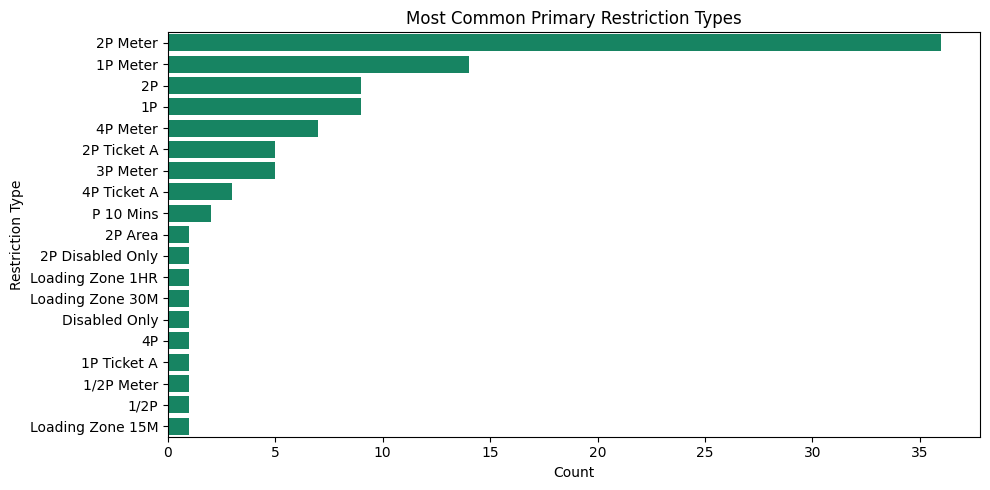

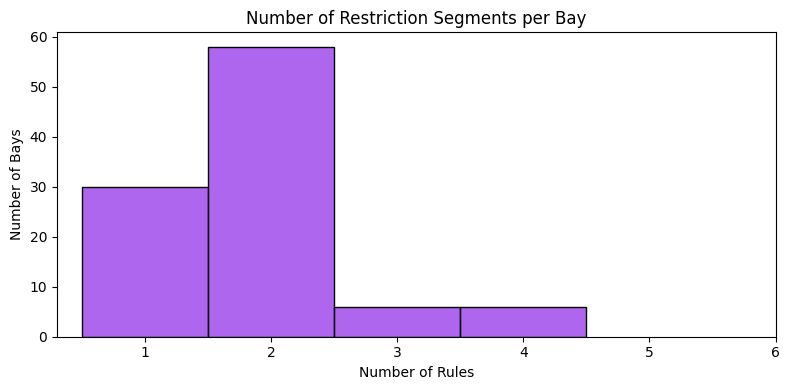

In [7]:
# Plot 1: distribution of primary restriction types
plt.figure(figsize=(10, 5))
sns.countplot(y=df_restrictions["typedesc1"], order=df_restrictions["typedesc1"].value_counts().index, color="#059669")
plt.title("Most Common Primary Restriction Types")
plt.xlabel("Count")
plt.ylabel("Restriction Type")
plt.tight_layout()
plt.show()

# Plot 2: number of rules per bay (non-null descriptions)
desc_cols = [f"description{i}" for i in range(1, 7)]
rule_counts = df_restrictions[desc_cols].notnull().sum(axis=1)

plt.figure(figsize=(8, 4))
sns.histplot(rule_counts, bins=range(1, 8), discrete=True, color="#9333EA", edgecolor="black")
plt.title("Number of Restriction Segments per Bay")
plt.xlabel("Number of Rules")
plt.ylabel("Number of Bays")
plt.xticks(range(1, 7))
plt.tight_layout()
plt.show()


<div class="usecase-body"><b>Restriction types:</b> short-stay metered parking dominates. Most bays in the sample are 1P or 2P meters which is what you would expect in a retail and office area, the council wants bays to turn over. A few labels such as <code>Loading Zone 30M 722</code> are one-offs which is a reminder that the rule text was entered by hand and is not perfectly consistent.</div>

<div class="usecase-body"><b>Rules per bay:</b> most bays have a single rule and almost none have more than three. For a driver this means the sign on the pole usually says one thing and the complicated multi-rule bays are the exception.</div>

<div class="usecase-body">Taken together the two charts set expectations for section 5: the restrictions data is clean enough to join to the sensors, but any feature built from the rule text would need the labels standardised first.</div>


<div id="section-4" class="usecase-section-heading"><b>4. Parking meter metadata</b></div>


<div class="usecase-body">The third live dataset describes the meters themselves: where each one is and how it can be paid. For the driver in the scenario this answers the payment part of the question since not everyone carries coins or a card.</div>


In [8]:
# Fetch a 100-row sample of the parking meter dataset
df_meters = fetch_sample("on-street-car-parking-meters-with-location")

print("df_meters shape:", df_meters.shape)
df_meters.head()


df_meters shape: (100, 9)


,barcode,creditcard,tapandgo,asset_id,meter_id,location_description,latitude,longitude,location
0,MPM1630443,Yes,Yes,1630443,PPARK2,Princes Park,-37.781878,144.961220,"{'lon': 144.9612197, 'lat': -37.7818785}"
1,MPM1647110,Yes,Yes,1647110,800D,St Kilda Road between Moubray Street and High ...,-37.848768,144.980396,"{'lon': 144.980396, 'lat': -37.8487678}"
2,MPM1647111,Yes,Yes,1647111,857C,Lansdowne Street between Wellington Parade and...,-37.813518,144.977841,"{'lon': 144.9778414, 'lat': -37.8135175}"
3,MPM1647115,Yes,Yes,1647115,813B,Commercial Road between St Kilda Road and Punt...,-37.845160,144.980200,"{'lon': 144.9802005, 'lat': -37.8451596}"
4,MPM1647116,Yes,Yes,1647116,828D,"Kings Domain, approximately 87m NE of Marquis ...",-37.825989,144.972369,"{'lon': 144.972369, 'lat': -37.8259892}"


<div class="usecase-body">This is the simplest of the three live datasets. Each row is one meter, with:</div>

<div class="usecase-list">

- <code>creditcard</code> and <code>tapandgo</code>: whether the meter accepts card and contactless payment
- <code>location_description</code>: a street-level description of where the meter stands
- <code>latitude</code> and <code>longitude</code>: its position, for mapping
- <code>barcode</code>, <code>asset_id</code> and <code>meter_id</code>: the council's internal identifiers

</div>

<div class="usecase-body">Note that there is no bay id here. Meters are linked to bays by proximity rather than by a shared key, so this dataset is used for mapping and payment information not joined into the sensor and restriction merge.</div>


<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1. Payment options and meter locations</b></div>


<div class="usecase-body">A quick check of completeness, then two views of the data. A pair of bar charts showing how many meters accept card and tap-and-go and a map of where the sampled meters are.</div>


In [9]:
# Column summary, missing values and the distinct payment values
df_meters.info()

print("\nMissing values per column:")
print(df_meters.isnull().sum())

print("\nUnique values in 'creditcard':", df_meters["creditcard"].unique())
print("Unique values in 'tapandgo':", df_meters["tapandgo"].unique())
print("\nUnique 'location_description' examples:")
print(df_meters["location_description"].dropna().unique()[:5])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   barcode               100 non-null    object 
 1   creditcard            99 non-null     object 
 2   tapandgo              100 non-null    object 
 3   asset_id              100 non-null    int64  
 4   meter_id              100 non-null    object 
 5   location_description  100 non-null    object 
 6   latitude              100 non-null    float64
 7   longitude             100 non-null    float64
 8   location              100 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 7.2+ KB

Missing values per column:
barcode                 0
creditcard              1
tapandgo                0
asset_id                0
meter_id                0
location_description    0
latitude                0
longitude               0
location                0
dtype: int64

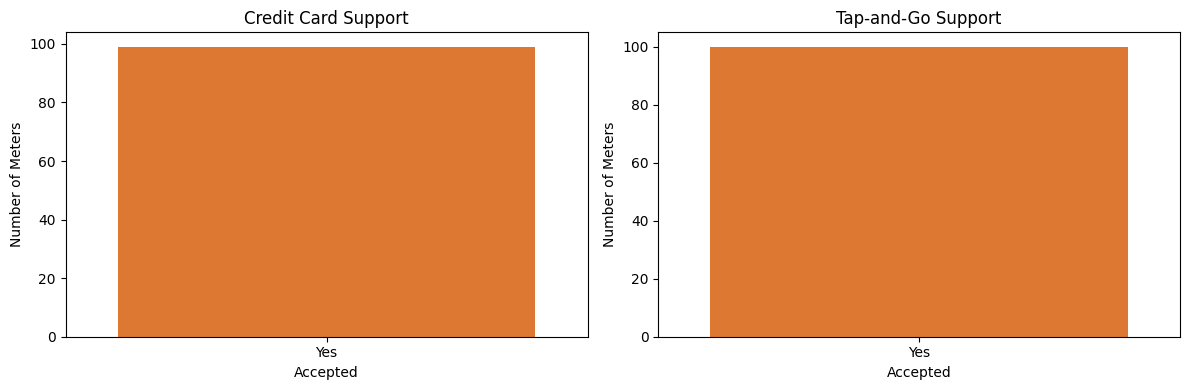

In [10]:
# Plot 1: credit card and tap-and-go support
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_meters, x="creditcard", ax=axes[0], color="#F97316")
axes[0].set_title("Credit Card Support")
axes[0].set_xlabel("Accepted")
axes[0].set_ylabel("Number of Meters")

sns.countplot(data=df_meters, x="tapandgo", ax=axes[1], color="#F97316")
axes[1].set_title("Tap-and-Go Support")
axes[1].set_xlabel("Accepted")
axes[1].set_ylabel("Number of Meters")

plt.tight_layout()
plt.show()


In [11]:
# Plot 2: meter locations on a map
map_meters = folium.Map(location=[-37.8136, 144.9631], zoom_start=13)

for _, row in df_meters.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4,
        color="#9333EA",
        fill=True,
        fill_opacity=0.7,
        popup=row["location_description"]
    ).add_to(map_meters)

map_meters


<div class="usecase-body">The good news for drivers is that almost every meter in the sample accepts both card and tap-and-go so payment method is rarely going to be the deciding factor in where to park. The single missing <code>creditcard</code> value is a data-entry gap rather than a meter that refuses cards.</div>

<div class="usecase-body">The map confirms the coordinates are sensible and shows meters lining the main CBD streets. Clicking a marker shows its street description which is the kind of label a parking app would display once it had chosen a bay for the driver.</div>


<div id="section-5" class="usecase-section-heading"><b>5. Merging the live datasets</b></div>


<div class="usecase-body">The City of Melbourne documents how these datasets connect: the parking bay sensors join to the bay restrictions on the bay id. To make that join work we need complete current snapshots of both datasets not samples. The <code>records</code> endpoint caps each request at 100 rows and two independent 100-row samples from datasets of thousands will almost never share ids. Instead we use the <code>exports</code> endpoint which returns the full dataset in one call.</div>

<div class="usecase-body">The cell below fetches both datasets in full, detects the join key by name in each, performs the merge and prints the share of sensors that found a matching restriction record.</div>


In [12]:
# Fetch complete current snapshots of both live datasets via the exports endpoint
BASE = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets"

def fetch_full(dataset_id):
    """Return the full current dataset as a DataFrame, or None if the API is disrupted."""
    try:
        for attempt in range(1, 4):
            r = requests.get(_with_key(f"{BASE}/{dataset_id}/exports/json?lang=en"), timeout=120)
            if r.status_code == 429:
                print(f"Rate-limited by the API (429). Waiting {30*attempt}s before retry {attempt}/3...")
                time.sleep(30 * attempt)
                continue
            r.raise_for_status()
            return pd.DataFrame(r.json())
        raise RuntimeError("API quota still exceeded after 3 attempts")
    except Exception as e:
        print(f"Could not fetch {dataset_id}: {e}")
        print("The City of Melbourne is upgrading its parking system and live datasets may be disrupted.")
        return None

sensors_full = fetch_full("on-street-parking-bay-sensors")
restr_full   = fetch_full("on-street-car-park-bay-restrictions")

if sensors_full is not None and restr_full is not None:
    print("sensors:", sensors_full.shape, "| restrictions:", restr_full.shape)
    print("sensor columns:", list(sensors_full.columns))
    print("restriction columns:", list(restr_full.columns))

    # The join key is the bay id; column naming differs slightly between datasets
    s_key = next((c for c in sensors_full.columns if c.lower() in ("kerbsideid", "bay_id", "bayid")), None)
    r_key = next((c for c in restr_full.columns if c.lower() in ("bay_id", "bayid", "kerbsideid")), None)
    print("join keys detected -> sensors:", s_key, "| restrictions:", r_key)

    sensors_full[s_key] = sensors_full[s_key].astype(str)
    restr_full[r_key]   = restr_full[r_key].astype(str)
    merged_live = sensors_full.merge(restr_full, left_on=s_key, right_on=r_key, how="left")

    match_rate = merged_live[r_key].notna().mean()
    print(f"merged: {merged_live.shape} | sensors with a matching restriction: {match_rate:.1%}")

sensors: (6324, 6) | restrictions: (4263, 62)
sensor columns: ['lastupdated', 'status_timestamp', 'zone_number', 'status_description', 'kerbsideid', 'location']
restriction columns: ['bayid', 'deviceid', 'description1', 'description2', 'description3', 'description4', 'description5', 'description6', 'disabilityext1', 'disabilityext2', 'disabilityext3', 'disabilityext4', 'disabilityext5', 'disabilityext6', 'duration1', 'duration2', 'duration3', 'duration4', 'duration5', 'duration6', 'effectiveonph1', 'effectiveonph2', 'effectiveonph3', 'effectiveonph4', 'effectiveonph5', 'effectiveonph6', 'endtime1', 'endtime2', 'endtime3', 'endtime4', 'endtime5', 'endtime6', 'exemption1', 'exemption2', 'exemption3', 'exemption4', 'exemption5', 'exemption6', 'fromday1', 'fromday2', 'fromday3', 'fromday4', 'fromday5', 'fromday6', 'starttime1', 'starttime2', 'starttime3', 'starttime4', 'starttime5', 'starttime6', 'today1', 'today2', 'today3', 'today4', 'today5', 'today6', 'typedesc1', 'typedesc2', 'typedes

<div class="usecase-body"><b>What the match rate tells us:</b> the join keys were detected correctly and both datasets were fetched in full yet at the time of writing only a per cent or two of live sensors find a matching restriction record. This is the City of Melbourne's parking system upgrade in action. The new sensor feed and the older restrictions dataset currently occupy largely different bay-id spaces so even a correctly specified join on the documented key returns few matches.</div>

<div class="usecase-body"> The match rate printed above is the health check. As the upgrade completes and the datasets realign, re-running this cell should show it rise. Nothing downstream depends on it. The analysis from the next section onward runs entirely on the historical archive.</div>


<div id="section-6" class="usecase-section-heading"><b>6. Historical parking events: the 2019 archive</b></div>


<div class="usecase-body">A single real-time snapshot can tell us what is happening <i>now</i> but it cannot tell us what usually happens at 2 pm on a Tuesday. For that we need repeated observations over time. The City of Melbourne archived its sensor event data by year and each record is an interval. A vehicle arrived at this bay at this time and departed at that time, or the bay sat vacant between these times. The <code>VehiclePresent</code> column distinguishes the two.</div>

<div class="usecase-body">This is the dataset that makes the scenario answerable. A driver asking about a future arrival time is asking a question about patterns and patterns only show up across many days.</div>


<div id="subsection-6-1" class="usecase-sub-section-heading"><b>6.1. Loading the extract</b></div>


<div class="usecase-body">The full 2019 archive is 42.7 million rows (717 MB compressed). This use case ships a pre-filtered extract in the <code>DEPENDENCIES</code> folder: <b>March 2019, eight central city areas, 11 columns, about 500,000 events (6.7 MB)</b>.</div>

<div class="usecase-body">The extract was built with the one-off code in the next cell shown for transparency. It is commented out because it needs the full archive on disk and takes several minutes to run, you do not need to run it to complete this use case. One filtering note: the archive contains an area literally named <code>All</code> (about 179,000 rows in March) which is an upstream artefact rather than a place and it is excluded from the extract.</div>


In [13]:
# One-off: how the extract was built from the full archive. Not needed to run this use case.
# Source: https://discover.data.vic.gov.au/dataset/on-street-car-parking-sensor-data-2019
# (717 MB zip; scanned in chunks, filtered, and saved compressed)
#
# CORE = ['Banks', 'Princes Theatre', 'Windsor', 'Twin Towers',
#         'Chinatown', 'City Square', 'Degraves', 'Library']
# KEEP = ['DeviceId', 'ArrivalTime', 'DepartureTime', 'DurationMinutes', 'StreetMarker',
#         'BayId', 'AreaName', 'StreetName', 'Sign', 'InViolation', 'VehiclePresent']
# first = True
# for chunk in pd.read_csv(archive_csv, chunksize=1_000_000, low_memory=False):
#     sel = chunk[chunk['ArrivalTime'].str.startswith('03/')]      # March (dates are MM/DD/YYYY)
#     sel = sel[sel['AreaName'].isin(CORE)][KEEP]
#     sel.to_csv('UC00163_parking_2019_march_core.csv.gz', mode='a', compression='gzip',
#                index=False, header=first)
#     first = False


In [14]:
# Load the historical extract from the DEPENDENCIES folder
EXTRACT = "UC00163_parking_2019_march_core.csv.gz"
candidates = [
    f"../DEPENDENCIES/{EXTRACT}",                # from usecases/FINALISED/ to usecases/DEPENDENCIES
    f"../../DEPENDENCIES/{EXTRACT}",             # if run from a per-use-case subfolder
    EXTRACT,                                     # same folder fallback
]
path = next((p for p in candidates if os.path.exists(p)), None)
if path is None:
    hits = glob.glob(f"../**/{EXTRACT}", recursive=True)
    path = hits[0] if hits else None
assert path is not None, f"Extract not found. Place {EXTRACT} in usecases/DEPENDENCIES/"

hist = pd.read_csv(path, low_memory=False)
print("loaded:", path)
print("shape:", hist.shape)
hist.head(3)


loaded: ../DEPENDENCIES/UC00163_parking_2019_march_core.csv.gz
shape: (508517, 11)


,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,BayId,AreaName,StreetName,Sign,InViolation,VehiclePresent
0,23914,03/21/2019 09:38:06 AM,03/21/2019 09:39:11 AM,1.0,1896N,1532,Twin Towers,COLLINS STREET,1P MTR M-SAT 7:30-18:30,False,False
1,23915,03/13/2019 10:13:10 AM,03/13/2019 10:55:49 AM,42.0,2374N,1753,Windsor,BOURKE STREET,1P MTR M-SAT 7:30-18:30,False,True
2,23914,03/18/2019 09:26:06 AM,03/18/2019 09:34:09 AM,8.0,1896N,1532,Twin Towers,COLLINS STREET,1P MTR M-SAT 7:30-18:30,False,True


<div id="subsection-6-2" class="usecase-sub-section-heading"><b>6.2. Cleaning the extract</b></div>


<div class="usecase-body">Every step in the cleaning cell corresponds to a real quirk of this archive. Numbers stored with thousands separators, timestamps in US date order, a documented sensor fault where departures were recorded before arrivals and multi-day "occupied" intervals that are stuck sensors rather than genuine parkers. The cell reports how many rows each check removed.</div>


In [15]:
# Clean the extract — every fix below corresponds to a real quirk in this archive
# 1. DurationMinutes contains a handful of values with thousands separators ('1,440'),
#    which makes the column mixed-type and breaks aggregation
hist["DurationMinutes"] = pd.to_numeric(
    hist["DurationMinutes"].astype(str).str.replace(",", ""), errors="coerce")

# 2. Parse the timestamps (US format: MM/DD/YYYY HH:MM:SS AM/PM)
FMT = "%m/%d/%Y %I:%M:%S %p"
hist["arrival"]   = pd.to_datetime(hist["ArrivalTime"], format=FMT, errors="coerce")
hist["departure"] = pd.to_datetime(hist["DepartureTime"], format=FMT, errors="coerce")

before = len(hist)
hist = hist.dropna(subset=["DurationMinutes", "arrival", "departure"])

# 3. The publisher documents that some sensors recorded departures before arrivals —
#    drop those non-positive durations
hist = hist[hist["departure"] > hist["arrival"]]

# 4. Extremely long "occupied" intervals are stuck sensors, not 25-day parkers —
#    cap at 24 hours (1440 minutes)
stuck = (hist["DurationMinutes"] > 1440).sum()
hist = hist[hist["DurationMinutes"] <= 1440]

print(f"dropped {before - len(hist)} problem rows ({stuck} of them stuck-sensor intervals over 24h)")
print(f"clean events: {len(hist):,} | bays: {hist.BayId.nunique()} | areas: {hist.AreaName.nunique()}")
print("date range:", hist.arrival.min(), "->", hist.arrival.max())

dropped 0 problem rows (0 of them stuck-sensor intervals over 24h)
clean events: 508,517 | bays: 342 | areas: 8
date range: 2019-03-01 00:00:00 -> 2019-03-31 23:59:47


<div class="usecase-body"><b>Why this cleaning matters:</b> each of these steps fixes something present in the full archive. Comma-formatted numbers make a whole column text, so any sum or mean fails or concatenates. Reversed timestamps are a documented sensor fault. And multi-day occupied intervals (the longest in the raw archive is over 25 days) are stuck sensors, leaving them in would let a handful of broken devices dominate every occupancy statistic.</div>

<div class="usecase-body">The shipped extract was built after these checks so they report zero rows dropped here. They are kept in the notebook deliberately. Anyone extending this use case to another month or year of the archive will need them.</div>


<div id="section-7" class="usecase-section-heading"><b>7. Availability patterns</b></div>


<div class="usecase-body">Because every interval is labelled with <code>VehiclePresent</code> availability has a direct empirical definition: <b>the share of bay-minutes that were vacant</b>. We weight by duration rather than counting events since a three-hour vacancy matters more to a driver than a three-minute one.</div>

<div class="usecase-body">This section measures that share by hour of day, then by day of week and by area. These are the patterns a driver planning ahead actually cares about.</div>


<div id="subsection-7-1" class="usecase-sub-section-heading"><b>7.1. Availability by hour of day</b></div>


<div class="usecase-body">Derive the hour, day of week and weekend flag from each event's arrival time, then compute the vacant share for each hour of the day across the whole month.</div>


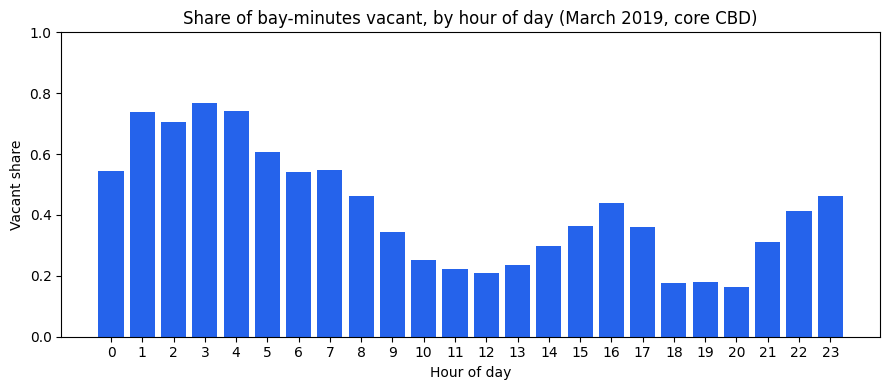

hour
0     0.544
1     0.738
2     0.705
3     0.768
4     0.741
5     0.607
6     0.543
7     0.548
8     0.463
9     0.344
10    0.250
11    0.222
12    0.211
13    0.236
14    0.297
15    0.362
16    0.440
17    0.360
18    0.176
19    0.180
20    0.162
21    0.312
22    0.414
23    0.463


In [16]:
# Availability by hour of day — share of bay-minutes vacant
hist["hour"] = hist["arrival"].dt.hour
hist["dow"] = hist["arrival"].dt.dayofweek       # 0 = Monday
hist["is_weekend"] = (hist["dow"] >= 5).astype(int)

vacant = hist[~hist["VehiclePresent"]]
by_hour = (vacant.groupby("hour")["DurationMinutes"].sum()
           / hist.groupby("hour")["DurationMinutes"].sum())

plt.figure(figsize=(9, 4))
plt.bar(by_hour.index, by_hour.values, color="#2563EB")
plt.title("Share of bay-minutes vacant, by hour of day (March 2019, core CBD)")
plt.xlabel("Hour of day"); plt.ylabel("Vacant share")
plt.xticks(range(0, 24)); plt.ylim(0, 1)
plt.tight_layout(); plt.show()
print(by_hour.round(3).to_string())

<div class="usecase-body"><b>Reading the daily rhythm:</b> the pattern is strong and easy to interpret. Overnight, most bay-time is vacant around 70 per cent or more in the small hours. Availability then falls steadily through the morning commute to a midday lull with roughly one bay-minute in five vacant between 10 am and 1 pm. It recovers a little mid-afternoon and then drops to its tightest point of the whole day in the early evening, around 6 to 8 pm.</div>

<div class="usecase-body">These eight areas cover Melbourne's restaurant and theatre areamand many restrictions also end around 6:30 pm, so cars arrive and stay longer. For the driver in the scenario the practical advice is already clear: arriving before 9 am or after 9 pm is easy, midday is hard, and Friday at 7 pm is the hardest of all.</div>


<div id="subsection-7-2" class="usecase-sub-section-heading"><b>7.2. Availability by day of week and area</b></div>


<div class="usecase-body">The same vacant-share calculation, grouped first by day of week and then by the eight CBD areas in the extract.</div>


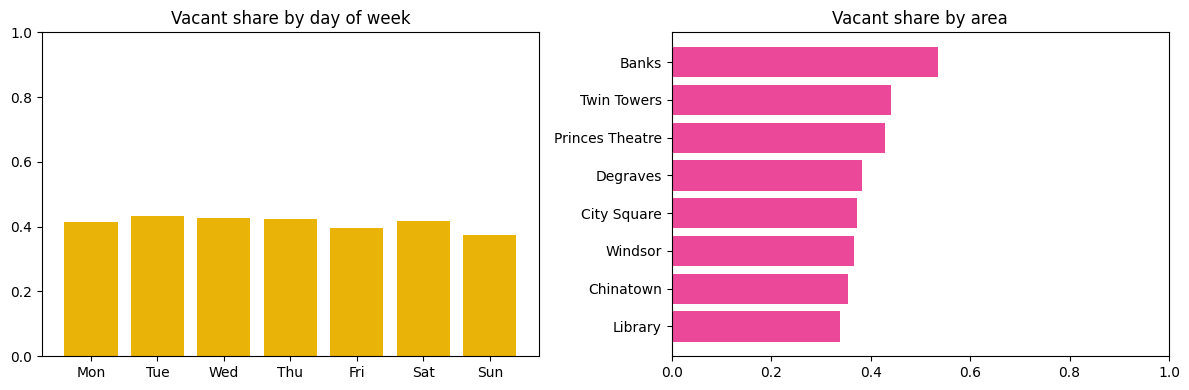

dow
0    0.414
1    0.435
2    0.426
3    0.423
4    0.396
5    0.418
6    0.373

AreaName
Library            0.339
Chinatown          0.355
Windsor            0.366
City Square        0.372
Degraves           0.383
Princes Theatre    0.429
Twin Towers        0.442
Banks              0.536


In [17]:
# Availability by day of week and by area
by_dow = (vacant.groupby("dow")["DurationMinutes"].sum()
          / hist.groupby("dow")["DurationMinutes"].sum())
by_area = (vacant.groupby("AreaName")["DurationMinutes"].sum()
           / hist.groupby("AreaName")["DurationMinutes"].sum()).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], by_dow.values, color="#EAB308")
axes[0].set_title("Vacant share by day of week"); axes[0].set_ylim(0, 1)
axes[1].barh(by_area.index, by_area.values, color="#EC4899")
axes[1].set_title("Vacant share by area"); axes[1].set_xlim(0, 1)
plt.tight_layout(); plt.show()
print(by_dow.round(3).to_string()); print(); print(by_area.round(3).to_string())

<div class="usecase-body"><b>Day of week barely moves, area matters more.</b> Weekday availability varies only a few percentage points across the week. Sunday is typically the tightest, which fits with unrestricted free parking encouraging longer stays. Location, separates clearly. Banks has more than half its bay-time vacant, while Library and Chinatown sit near a third.</div>

<div class="usecase-body">For the model this sets expectations. Hour of day should dominate, area should contribute and day of week should add only a little.</div>


<div id="section-8" class="usecase-section-heading"><b>8. Modelling: predicting bay availability</b></div>


<div class="usecase-body"> given a <b>time</b> and a <b>place</b>, how likely is a bay to be vacant? Each historical interval becomes a training example. The features are the hour, day of week, weekend flag and area. The label is whether the bay was vacant and each example is weighted by its duration in minutes, so long intervals count for more, matching the bay-minutes definition of availability above.</div>

<div class="usecase-body">To judge the model honestly we compare it against two baselines: always predicting the majority class, and simply looking up the empirical vacant rate for that hour and area.</div>


In [18]:
# Train / evaluate: Random Forest vs two honest baselines
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix

features = pd.get_dummies(hist[["hour", "dow", "is_weekend", "AreaName"]], columns=["AreaName"])
target = (~hist["VehiclePresent"]).astype(int)          # 1 = vacant
weights = hist["DurationMinutes"].values

X_tr, X_te, y_tr, y_te, w_tr, w_te = train_test_split(
    features, target, weights, test_size=0.25, random_state=42, stratify=target)

clf = RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
clf.fit(X_tr, y_tr, sample_weight=w_tr)
pred = clf.predict(X_te)

print("model     accuracy:", round(accuracy_score(y_te, pred, sample_weight=w_te), 3),
      "| balanced:", round(balanced_accuracy_score(y_te, pred, sample_weight=w_te), 3),
      "| F1:", round(f1_score(y_te, pred, sample_weight=w_te), 3))

# Baseline 1 — majority class
maj = int(y_tr.value_counts().idxmax())
print("majority  accuracy:", round(accuracy_score(y_te, [maj]*len(y_te), sample_weight=w_te), 3))

# Baseline 2 — empirical lookup: vacant rate per (hour, area) on the training split
tr = hist.loc[X_tr.index]
lookup = (tr[~tr.VehiclePresent].groupby(["hour","AreaName"]).DurationMinutes.sum()
          / tr.groupby(["hour","AreaName"]).DurationMinutes.sum()).rename("rate")
te = hist.loc[X_te.index]
te_rate = te.merge(lookup.reset_index(), on=["hour","AreaName"], how="left")["rate"].fillna(0.5)
print("lookup    accuracy:", round(accuracy_score(y_te, (te_rate > 0.5).astype(int), sample_weight=w_te), 3))

print("\nconfusion matrix (weighted, rows=actual, cols=predicted):")
print(confusion_matrix(y_te, pred, sample_weight=w_te).round(0))
print("\ntop feature importances:")
imp = pd.Series(clf.feature_importances_, index=features.columns).sort_values(ascending=False)
print(imp.head(8).round(3).to_string())

model     accuracy: 0.703 | balanced: 0.681 | F1: 0.607
majority  accuracy: 0.594
lookup    accuracy: 0.685

confusion matrix (weighted, rows=actual, cols=predicted):
[[1614734.  405528.]
 [ 604386.  778860.]]

top feature importances:
hour                        0.814
dow                         0.066
AreaName_Banks              0.036
is_weekend                  0.020
AreaName_Library            0.016
AreaName_Twin Towers        0.011
AreaName_Princes Theatre    0.011
AreaName_City Square        0.008


<div class="usecase-body"><b>Interpreting the results:</b> three comparisons matter in the above output. The model against the majority baseline (0.70 versus 0.59) shows it learned something real. The model against the lookup table (0.70 versus 0.69) shows the classifier adds only a little beyond memorised averages. With only time and area as features that gap is expected to be modest, the predictable signal is the daily rhythm itself.</div>

<div class="usecase-body">The feature importances confirm what the availability charts already showed. Hour of day carries over 80 per cent of the importance, area contributes and day of week is minor.</div>

<div class="usecase-body">Limits: this model knows nothing about weather, events, roadworks or holidays and it is trained on pre-pandemic 2019 patterns. A production system would retrain on current data as the council's upgraded sensor feed matures.</div>


<div id="section-9" class="usecase-section-heading"><b>9. Predicting availability for an arrival time</b></div>


<div class="usecase-body">This closes the loop on the user story. Given an area and an intended arrival time, the function below returns both the model's probability that a bay is vacant and the empirical rate from the archive for that hour and area. These are the two views a real app would show a driver: the model's estimate and the plain historical average.</div>


In [19]:
# The user story, answered
def predict_availability(area, when):
    """area: one of the core CBD area names; when: any datetime string, e.g. '2026-08-04 14:00'"""
    t = pd.Timestamp(when)
    row = pd.DataFrame([{"hour": t.hour, "dow": t.dayofweek, "is_weekend": int(t.dayofweek >= 5),
                         "AreaName": area}])
    row = pd.get_dummies(row, columns=["AreaName"]).reindex(columns=features.columns, fill_value=0)
    prob = clf.predict_proba(row)[0, 1]
    emp = lookup.get((t.hour, area), float("nan"))
    print(f"{area}, {t.strftime('%A %H:%M')}  ->  model P(vacant) = {prob:.2f}"
          + (f" | historical vacant share = {emp:.2f}" if pd.notna(emp) else ""))

predict_availability("Chinatown", "2026-08-04 14:00")        # Tuesday 2 pm
predict_availability("Princes Theatre", "2026-08-07 19:30")  # Friday 7:30 pm
predict_availability("Banks", "2026-08-09 08:00")            # Sunday 8 am

Chinatown, Tuesday 14:00  ->  model P(vacant) = 0.25 | historical vacant share = 0.23
Princes Theatre, Friday 19:30  ->  model P(vacant) = 0.12 | historical vacant share = 0.11
Banks, Sunday 08:00  ->  model P(vacant) = 0.63 | historical vacant share = 0.52


<div class="usecase-body">The three example calls match three kinds of trip: a Tuesday 2 pm meeting in Chinatown, a Friday evening at the theatre and an early Sunday errand in the Banks area. The model and the historical average agree closely in each caseand the numbers translate directly into advice. Expect to circle for a while on a Tuesday afternoon, do not count on a bay outside the theatre on Friday night and Sunday morning is easy.</div>

<div class="usecase-body"><b>From notebook to app:</b> these calls are the essence of the assistant the scenario describes. A front end (Streamlit is a natural fit) would wrap this function with a destination search and show the nearest bays on the live map from section 2 with the live API supplying <i>now</i> and the model supplying <i>usually</i>.</div>


<div id="section-10" class="usecase-section-heading"><b>10. Saving the trained model</b></div>


<div class="usecase-body">Export the trained model as a <code>.pkl</code> file using <code>joblib</code> so it can be loaded by a web app or dashboard without retraining. The feature column order is saved alongside it since the model expects its inputs in exactly that order.</div>


In [20]:
# Save the trained model and its feature column order for reuse
import joblib
joblib.dump({"model": clf, "feature_columns": list(features.columns)},
            "rf_parking_availability_model.pkl")
print("saved rf_parking_availability_model.pkl")

saved rf_parking_availability_model.pkl


<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>


<div class="usecase-body">This use case set out to answer "if I arrive at this part of the CBD at this time how likely am I to find a bay?" Answering it properly meant combining the City of Melbourne's live parking feeds with a month of archived sensor events, working through several real data quality and data transition issues along the way and building a model that is judged against honest baselines.</div>


<div class="usecase-sub-section-heading"><b>What we achieved in this analysis</b></div>

<div class="usecase-list">

- Connected to the live City of Melbourne parking APIs and joined the sensor and restriction datasets on their documented bay-id key, diagnosing why the join currently returns few matches
- Worked with the archived 2019 sensor data at realistic scale, filtering 42.7 million events down to a useable extract
- Found and fixed genuine data quality issues: mixed-type numerics, reversed timestamps, stuck sensors and an artefact area category
- Measured availability as vacant bay-minutes, revealing a strong daily rhythm with a midday trough and an even tighter early-evening 
- Trained a duration-weighted Random Forest and evaluated it against a majority baseline and an empirical lookup table
- Delivered a prediction function that answers the scenario directly: area plus arrival time in, probability of a vacant bay out

</div>

<div class="usecase-sub-section-heading"><b>What we learned from this analysis</b></div>

<div class="usecase-list">

- Temporal prediction needs repeated observations, which is why the historical archive was essential
- Hour of day dominates parking availability, area matters and day of week adds surprisingly little

</div>

<div class="usecase-sub-section-heading"><b>Observations for further opportunities</b></div>

<div class="usecase-list">

- Wrap the prediction function and live map in a simple web app (for example Streamlit) with destination search
- Extend the extract to more months or areas and add features such as public holidays and major events
- Retrain on post-upgrade live data as the City of Melbourne's new parking system comes online and compare against these 2019 patterns

</div>
